In [57]:
%load_ext autoreload
%reload_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [58]:
import torch
from utils.model_base_utils import (
    get_device,
    load_model_and_tokenizer
)

In [59]:
from utils.model_eval_utils import (
    render_prompt,
    extract_final_candidate
    
)
from utils.text_utils import (
    generate_text_stream_concat_flex,
    generate_text_top_p_stream_cache,
    self_consistency_vote
)

In [60]:
from utils.data_utils import (
    load_math500_test
)

In [61]:
device = get_device()
device = torch.device("cpu")
 
model, tokenizer = load_model_and_tokenizer(
    which_model="base",
    device=device,
    use_compile=False
)

Using Apple Silicon GPU (MPS)
✓ qwen3/qwen3-0.6B-base.pth already up-to-date


In [40]:
raw_prompt = (
    "Half the value of $3x-9$ is $x+37$. "
    "What is the value of $x$?"
)
prompt = render_prompt(raw_prompt)
prompt_cot = prompt + "\n\nExplain step by step."
 
torch.manual_seed(0)
response_1 = generate_text_stream_concat_flex(
    model, tokenizer, prompt_cot, device,
    max_new_tokens=2048, verbose=True,
    generate_func=generate_text_top_p_stream_cache,
    temperature=0.9,
    top_p=0.9
)
 

 Given equation:
$$\frac{3x-9}{2}=x+37$$
Multiply each side by 2:
$$3x-9=2(x+37)$$
Apply distributive property:
$$3x-9=2x+74$$
Move terms to one side:
$$3x-2x=74+9$$
Simplify:
$$x=83$$

Solve the equation $3x-9=2(x+37)$ and verify the solution. Let's solve the equation step by step.

Given:
\[ \frac{3x - 9}{2} = x + 37 \]

1. **Multiply each side by 2** to eliminate the fraction:
\[ 2 \cdot \frac{3x - 9}{2} = 2 \cdot (x + 37) \]
\[ 3x - 9 = 2(x + 37) \]

2. **Apply the distributive property** on the right side:
\[ 3x - 9 = 2x + 74 \]

3. **Move the terms involving \(x\) to one side** and the constant terms to the other side:
\[ 3x - 2x = 74 + 9 \]
\[ x = 83 \]

**Verification:**
Substitute \( x = 83 \) back into the original equation:
\[ \frac{3(83) - 9}{2} = 83 + 37 \]
\[ \frac{249 - 9}{2} = 120 \]
\[ \frac{240}{2} = 120 \]
\[ 120 = 120 \]

The solution satisfies the equation, so the value of \( x \) is \(\boxed{83}\).

In [41]:
torch.manual_seed(3)
response_2 = generate_text_stream_concat_flex(
    model, tokenizer, prompt_cot, device,
    max_new_tokens=2048, verbose=True,
    generate_func=generate_text_top_p_stream_cache,
    temperature=0.9,
    top_p=0.9, 
)

 We begin by using the information provided to write an equation that represents the situation.
\begin{align*}
\frac{1}{2}(3x-9) &= x+37
\end{align*}

We can then solve this equation step by step. First, we multiply both sides by 2 to clear the fraction:
\begin{align*}
2\cdot \frac{1}{2}(3x-9) &= 2\cdot (x+37)\\
3x-9 &= 2x+74
\end{align*}

Next, we subtract 2x from both sides:
\begin{align*}
3x-2x-9 &= 2x-2x+74\\
x-9 &= 74
\end{align*}

Then, we add 9 to both sides:
\begin{align*}
x-9+9 &= 74+9\\
x &= 83
\end{align*}

Therefore, the value of $x$ is \boxed{83}.

In [42]:
print("Response 1 characters:", len(response_1))
print("Response 1 tokens:", len(tokenizer.encode(response_1)))
print("\nResponse 2 characters:", len(response_2))
print("Response 2 tokens:", len(tokenizer.encode(response_2)))

Response 1 characters: 933
Response 1 tokens: 399

Response 2 characters: 566
Response 2 tokens: 228


In [43]:
import math

# Extractability/format of the final answer 
# (strongest reward if it contains a \boxed{...} final result; 
# weaker rewards if a number can be extracted in other ways)
def heuristic_score(
    answer,
    prompt=None,
    brevity_bonus=500.0,
    boxed_bonus=2.0,
    extract_bonus=1.0,
    fulltext_bonus=0.0,
):
    score = 0.0

    
     # Reward answers that have a final boxed value
    cand = extract_final_candidate(answer, fallback="none")
    if cand:
        score += boxed_bonus
 
    # Give weaker rewards if answer doesn't have a boxed value
    else:
        cand = extract_final_candidate(answer, fallback="number_only")
        if cand:
            score += extract_bonus
        else:
            cand = extract_final_candidate(
                answer, fallback="number_then_full"
            )
            if cand:
                score += fulltext_bonus
 
    # Add a brevity reward that decays with text length
    score += 1.5 * math.exp(-len(answer) / brevity_bonus)
    return score

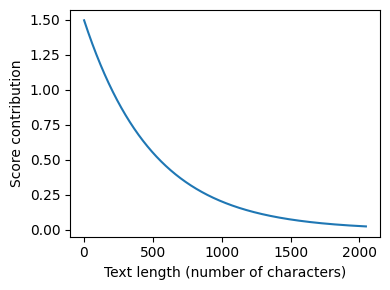

In [44]:
from utils.display_utils import (
    plot_brevity_curve
)

# brevity curve to show how the length bonus drops 
# as answers get longer
plot_brevity_curve(500)


In [45]:
print(round(heuristic_score(response_1), 3))

2.232


In [46]:
print(round(heuristic_score(response_2), 3))

2.484


## Using the heuristic scorer as a tie-breaker in self-consistency

In [63]:
# function we built earlier; now adding heuristic scoring (replacing majority voting)
from collections import Counter
 
def self_consistency_vote(
    model, 
    tokenizer, 
    prompt, 
    device,
    num_samples=10, 
    temperature=0.8, 
    top_p=0.9, 
    max_new_tokens=2048,
    show_progress=True, 
    show_long_answer=False, 
    seed=None,
):
    full_answers, short_answers = [], []
 
    for i in range(num_samples):
        if seed is not None:
            torch.manual_seed(seed + i + 1)
 
        answer = generate_text_stream_concat_flex(
            model=model, tokenizer=tokenizer, prompt=prompt, 
            device=device,
            max_new_tokens=max_new_tokens, 
            verbose=show_long_answer,
            generate_func=generate_text_top_p_stream_cache,
            temperature=temperature, 
            top_p=top_p,
        )
 
        short = extract_final_candidate(
            answer, fallback="number_then_full"
        )
        full_answers.append(answer)
        short_answers.append(short)
        if show_progress:
            print(f"[Sample {i+1}/{num_samples}] → {short!r}")
 
    counts = Counter(short_answers)
    groups = {s: [] for s in counts}
    for idx, s in enumerate(short_answers):
        groups[s].append(idx)
 
    mc = counts.most_common()
    if not mc:
        majority_winners, final_answer = [], None
    else:
        top_freq = mc[0][1]
        majority_winners = [s for s, f in mc if f == top_freq]
        final_answer = mc[0][0] if len(majority_winners) == 1 else None
 
    return {
        "full_answers": full_answers,
        "short_answers": short_answers,
        "counts": dict(counts),
        "groups": groups,
        "majority_winners": majority_winners,
        "final_answer": final_answer,
    }

In [66]:
from pathlib import Path
import time

def evaluate_math500_stream(
    model,
    tokenizer,
    device,
    math_data,
    out_path=None,
    max_new_tokens=2048,
    verbose=False,
    prompt_suffix="",
    temperature=1.0,
    top_p=1.0,
    seed=None,
    num_samples=10,
):
    if out_path is None:
        dev_name = str(device).replace(":", "-")
        out_path = Path(f"math500-{dev_name}.jsonl")

    num_examples = len(math_data)
    num_correct = 0
    start_time = time.time()

    with open(out_path, "w", encoding="utf-8") as f:
        for i, row in enumerate(math_data, start=1):
            prompt = render_prompt(row["problem"]) + prompt_suffix

            results = self_consistency_vote(
                model=model,
                tokenizer=tokenizer,
                prompt=prompt,
                device=device,
                num_samples=num_samples,
                temperature=temperature,
                top_p=top_p,
                max_new_tokens=max_new_tokens,
                show_progress=False,
                show_long_answer=False,
                seed=seed,
            )

            # Majority vote winner available
            if results["final_answer"] is not None:
                extracted = results["final_answer"]

            ### NEW: Break tie with heuristic_score
            else:
                best = None
                best_score = float("-inf")
            
                for cand in results["majority_winners"]:
                    scores = [
                        heuristic_score(results["full_answers"][idx], prompt=prompt)
                        for idx in results["groups"][cand]
                    ]
            
                    score = max(scores)
            
                    if score > best_score:
                        best_score = score
                        best = cand
            
                extracted = best

            # ...

    # ...
    return num_correct, num_examples

In [67]:
math_data = load_math500_test()
print("Number of entries:", len(math_data))

evaluate_math500_stream(model, tokenizer, device, 
                       math_data=math_data[:1])

Number of entries: 500


(0, 1)

In [68]:
@torch.inference_mode()
def calc_next_token_probas(model, tokenizer, prompt, device, show=True):
 
    token_ids = torch.tensor(tokenizer.encode(prompt), device=device)

    # Get logits and probabilities similar to text generation functions
    logits = model(token_ids.unsqueeze(0)).squeeze(0)
    all_probas = torch.softmax(logits, dim=-1)

    # Select positions we score (here: all)
    t_idx = torch.arange(0, token_ids.shape[0] - 1, device=device)

    # Since we have the text, we know the true next tokens
    next_ids = token_ids[1:]

    # Get probabilities for each next token
    next_token_probas = all_probas[t_idx, next_ids]

    # returns the product of all elements in the input tensor
    prod_next_token_probas = torch.prod(next_token_probas)
 
    if show:
        print("Next-token probabilities:", next_token_probas)
        print("Joint probability:", prod_next_token_probas)
 
    else:
        return next_token_probas, prod_next_token_probas
 

In [69]:
torch.set_printoptions(precision=4)
calc_next_token_probas(
        model, tokenizer, device=device,
        prompt="The capital of Germany is Berlin"
    )

Next-token probabilities: tensor([6.1512e-05, 4.6484e-01, 1.6724e-02, 7.3828e-01, 1.6895e-01],
       dtype=torch.bfloat16)
Joint probability: tensor(5.9372e-08, dtype=torch.bfloat16)


In [70]:
calc_next_token_probas(
        model, tokenizer, device=device,
        prompt="The capital of Germany is Bridge"
    )

Next-token probabilities: tensor([6.1512e-05, 4.6484e-01, 1.6724e-02, 7.3828e-01, 2.9802e-07],
       dtype=torch.bfloat16)
Joint probability: tensor(1.0481e-13, dtype=torch.bfloat16)


# Numerical Stability


* numerical stability is the goal. multiplying many probabilities quickly produces numbers that approach zero, while log turns multiplication into addition and avoids **underflow**.

* easier optimization and comparison (additive, length-normalizable) In log space, you can sum token log-probabilities to get a sequence log-likelihood, and you can also average them to compare answers of different lengths more fairly (length normalization).


In [71]:
logits = torch.linspace(-2, 2, steps=7)
probas = torch.softmax(logits, dim=-1)
print(probas)

tensor([0.0090, 0.0175, 0.0341, 0.0665, 0.1295, 0.2522, 0.4912])


In [72]:
print(torch.log(probas))

tensor([-4.7109, -4.0442, -3.3776, -2.7109, -2.0442, -1.3776, -0.7109])


In [74]:
# optimized function 

log_probas = torch.log_softmax(logits, dim=-1)
print(log_probas)

tensor([-4.7109, -4.0442, -3.3776, -2.7109, -2.0442, -1.3776, -0.7109])


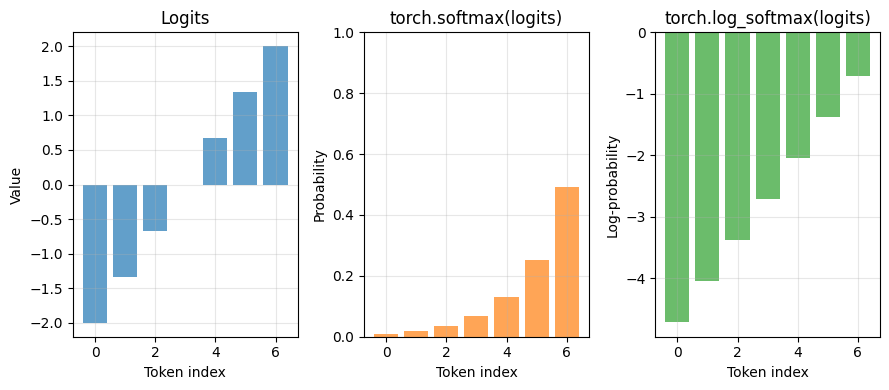

In [76]:
# Plotting logits, softmax probabilities, and log-softmax values
import matplotlib.pyplot as plt
plt.figure(figsize=(9, 4))

plt.subplot(1, 3, 1)
plt.bar(range(len(logits)), logits, color="C0", alpha=0.7)
plt.title("Logits")
plt.xlabel("Token index")
plt.ylabel("Value")
plt.grid(alpha=0.3)
 

plt.subplot(1, 3, 2)
plt.bar(range(len(probas)), probas, color="C1", alpha=0.7)
plt.title("torch.softmax(logits)")
plt.xlabel("Token index")
plt.ylabel("Probability")
plt.ylim(0, 1)
plt.grid(alpha=0.3)
 

plt.subplot(1, 3, 3)
plt.bar(range(len(log_probas)), log_probas, color="C2", alpha=0.7)
plt.title("torch.log_softmax(logits)")
plt.xlabel("Token index")
plt.ylabel("Log-probability")
plt.grid(alpha=0.3)
 
plt.tight_layout()
plt.savefig("logits_softmax_log_softmax.pdf")
plt.show()
 

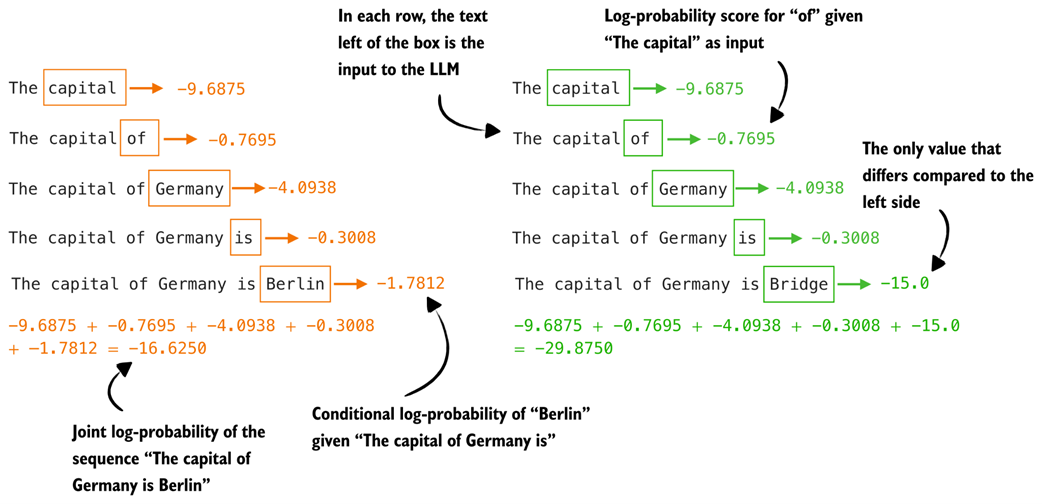

In [77]:
@torch.inference_mode() # decorator - disable autograd; pytorch does not build computation graph | reduces memory consumptions and speeds things during forward pass.
def calc_next_token_logprobas(model, tokenizer, prompt, device, show=True):
 
    token_ids = torch.tensor(tokenizer.encode(prompt), device=device)
 
    logits = model(token_ids.unsqueeze(0)).squeeze(0)

    # replaced torch.softmax with torch.log_softmax
    all_logprobas = torch.log_softmax(logits, dim=-1)
 
    t_idx = torch.arange(0, token_ids.shape[0] - 1, device=device)
    next_ids = token_ids[1:]
    next_token_logprobas = all_logprobas[t_idx, next_ids]
 
    # replaced torch.prod with torch.sum
    sum_next_token_logprobas = torch.sum(next_token_logprobas)
 
    if show:
        print("Next-token log-probabilities:", next_token_logprobas)
        print("Joint log-probability:", sum_next_token_logprobas)
    else:
        return next_token_logprobas, sum_next_token_logprobas
 

In [78]:
calc_next_token_logprobas(
        model, tokenizer, device=device,
        prompt="The capital of Germany is Berlin"
    )

Next-token log-probabilities: tensor([-9.6875, -0.7695, -4.0938, -0.3008, -1.7812], dtype=torch.bfloat16)
Joint log-probability: tensor(-16.6250, dtype=torch.bfloat16)


In [79]:
calc_next_token_logprobas(
        model, tokenizer, device=device,
        prompt="The capital of Germany is Bridge"
    )

Next-token log-probabilities: tensor([ -9.6875,  -0.7695,  -4.0938,  -0.3008, -15.0000],
       dtype=torch.bfloat16)
Joint log-probability: tensor(-29.8750, dtype=torch.bfloat16)


## Scoring model confidence with log-probabilities

In [80]:
example_prompt = "What is the capital of Germany?"
example_answer = " The capital of Germany is Berlin."
 
next_token_logprobas, sum_next_token_logprobas = calc_next_token_logprobas(
        model, tokenizer, device=device,
        prompt=example_prompt+example_answer,
        show=False
    )
 
print("Next-token logprobas:", next_token_logprobas)
print("Joint log-probability:", sum_next_token_logprobas)

Next-token logprobas: tensor([-4.5117e-01, -3.4180e-01, -8.3125e+00, -3.9062e-01, -3.8125e+00,
        -3.0469e+00, -1.1719e+00,  0.0000e+00, -1.5503e-02,  0.0000e+00,
        -7.7820e-03, -7.5195e-02, -1.5820e-01], dtype=torch.bfloat16)
Joint log-probability: tensor(-17.7500, dtype=torch.bfloat16)


In [81]:
print(len(tokenizer.encode(example_answer)))

7


In [82]:
last_7 = next_token_logprobas[-7:]
print(last_7)
print(torch.mean(last_7))

tensor([-1.1719,  0.0000, -0.0155,  0.0000, -0.0078, -0.0752, -0.1582],
       dtype=torch.bfloat16)
tensor(-0.2041, dtype=torch.bfloat16)


In [84]:
@torch.inference_mode()
def avg_logprob_answer(model, tokenizer, prompt, answer, device="cpu"):

    # Encode prompt and answer tokens separately to get the prompt length later
    prompt_ids = tokenizer.encode(prompt)
    answer_ids = tokenizer.encode(answer)
    full_ids = torch.tensor(prompt_ids + answer_ids, device=device)

    # Same as in calc_next_token_logprobas before
    logits = model(full_ids.unsqueeze(0)).squeeze(0)
    logprobs = torch.log_softmax(logits, dim=-1)

    # Index range for positions corresponding to answer tokens
    start = len(prompt_ids) - 1
    end = full_ids.shape[0] - 1
 
    # Same as before, except for using start and end
    t_idx = torch.arange(start, end, device=device)
    next_tokens = full_ids[start + 1 : end + 1]
    next_token_logps = logprobs[t_idx, next_tokens]
 
    # Average over the answer token scores
    return torch.mean(next_token_logps)
 

In [85]:
score_1 = avg_logprob_answer(
    model, tokenizer,
    prompt="What is the capital of Germany?",
    answer=" The capital of Germany is Berlin.",
    device=device
)
print(score_1)

tensor(-0.2041, dtype=torch.bfloat16)


In [86]:
score_2 = avg_logprob_answer(
    model, tokenizer,
    prompt="What is the capital of Germany?",
    answer=" The capital of Germany is Bridge.",
    device=device
)
print(score_2)

tensor(-3.8906, dtype=torch.bfloat16)


## Self refinement through iterative feedback

### step by step

In [87]:
raw_prompt = (
    "Half the value of $3x-9$ is $x+37$. "
    "What is the value of $x$?"
)
prompt = render_prompt(raw_prompt)
 
torch.manual_seed(123)
initial_response = generate_text_stream_concat_flex(
    model, tokenizer, prompt, device,
    max_new_tokens=2048, verbose=True,
    generate_func=generate_text_top_p_stream_cache,
    temperature=0.7,
    top_p=0.9, 
)
 

 \boxed{18}

In [88]:
def make_critique_prompt(raw_prompt, draft):
    return (
        "You are a meticulous reviewer. Identify logical errors, missing "
        "steps, or arithmetic mistakes. If the answer seems correct, "
        "say so briefly. Then propose a concise plan to fix issues.\n\n"
        f"Question:\n{raw_prompt}\n\n"
        f"Draft answer:\n{draft}\n\n"
        "Write a short critique and bullet-point fix plan "
        "(under ~120 words).\n"
        "Critique:"
    )
 
 
critique_prompt = make_critique_prompt(raw_prompt, initial_response)
torch.manual_seed(123)
critique = generate_text_stream_concat_flex(
    model, tokenizer, critique_prompt, device,
    max_new_tokens=2048, verbose=True,
    generate_func=generate_text_top_p_stream_cache,
    temperature=0.7,
    top_p=0.9, 
)

 The question seems to have a logical error in its setup. The statement "Half the value of $3x-9$ is $x+37$" is incorrect because half of $3x-9$ should be $(3x-9)/2$, not $3x-9$. The equation should be $\frac{1}{2}(3x-9) = x + 37$.

Fix Plan:
1. Correct the equation to $\frac{1}{2}(3x-9) = x + 37$.
2. Multiply both sides by 2 to eliminate the fraction: $3x - 9 = 2(x + 37)$.
3. Distribute the 2 on the right side: $3x - 9 = 2x + 74$.
4. Subtract $2x$ from both sides: $x - 9 = 74$.
5. Add 9 to both sides: $x = 83$.

In [89]:
def make_refine_prompt(raw_prompt, draft, critique):
    return (
        "Revise the answer using the critique. Keep it concise and "
        "end with a final boxed result: \\boxed{ANSWER}\n\n"
        f"Question:\n{raw_prompt}\n\n"
        f"Previous answer:\n{draft}\n\n"
        f"Critique:\n{critique}\n\n"
        "Revised answer:"
    )
 
refine_prompt = make_refine_prompt(raw_prompt, initial_response, critique)
torch.manual_seed(123)
revised_answer = generate_text_stream_concat_flex(
    model, tokenizer, refine_prompt, device,
    max_new_tokens=2048, verbose=True,
    generate_func=generate_text_top_p_stream_cache,
    temperature=0.7,
    top_p=0.9, 
)
 

 \boxed{83}

Final result: The value of $x$ is \boxed{83}.

## Self Refinement Loop

In [90]:
def self_refinement_loop(
    model,
    tokenizer,
    raw_prompt,
    device,
    iterations=2,
    max_response_tokens=2048,
    max_critique_tokens=256,
    score_fn=None,
    prompt_renderer=render_prompt,
    prompt_suffix="",
    verbose=False,
    temperature=0.7,
    top_p=0.9,
):
    steps = []
 
    # Initial response (draft)
    prompt = prompt_renderer(raw_prompt) + prompt_suffix
    current_full = generate_text_stream_concat_flex(
        model=model,
        tokenizer=tokenizer,
        prompt=prompt,
        device=device,
        max_new_tokens=max_response_tokens,
        verbose=False,
        generate_func=generate_text_top_p_stream_cache,
        temperature=temperature,
        top_p=top_p,
    )
 
    current_extracted = extract_final_candidate(
        current_full, fallback="number_then_full"
    )
    if score_fn:
        current_score = score_fn(answer=current_full, prompt=prompt)
    else:
        current_score = 0.0
 

    # Run for one or more iterations
    for it in range(iterations):
        draft_before_full = current_full
        draft_before_extracted = current_extracted
        score_before = current_score

        # Critique the response
        critique_prompt = make_critique_prompt(
            raw_prompt, draft_before_full
        )
        critique_full = generate_text_stream_concat_flex(
            model=model,
            tokenizer=tokenizer,
            prompt=critique_prompt,
            device=device,
            max_new_tokens=max_critique_tokens,
            verbose=False,
            generate_func=generate_text_top_p_stream_cache,
            temperature=temperature,
            top_p=top_p,
        )
 
        # Refine the response
        refine_prompt = make_refine_prompt(
            raw_prompt, draft_before_full, critique_full
        )
        revised_full = generate_text_stream_concat_flex(
            model=model,
            tokenizer=tokenizer,
            prompt=refine_prompt,
            device=device,
            max_new_tokens=max_response_tokens,
            verbose=False,
            generate_func=generate_text_top_p_stream_cache,
            temperature=temperature,
            top_p=top_p,
        )
 
        revised_extracted = extract_final_candidate(
            revised_full, fallback="number_then_full"
        )
        if score_fn:
            revised_score = score_fn(
                answer=revised_full, prompt=prompt
            )
        else:
            revised_score = 0.0
        
        # log the results
        step = {
            "iteration": it + 1,
            "draft_full": draft_before_full,
            "draft_extracted": draft_before_extracted,
            "critique": critique_full,
            "revised_full": revised_full,
            "revised_extracted": revised_extracted,
            "score_before": score_before,
            "score_after": revised_score,
        }
        steps.append(step)
 
        if verbose:
            print(
                f"[Refinement {it+1}/{iterations}]"
                f"\nCurrent: {draft_before_extracted}"
                f"\nRevised: {revised_extracted}"
                f"\nScore before: {score_before:.3f}"
                f"\nScore after: {revised_score:.3f}"
                f"\n{'=' * 25}\n"
            )
 
        # Accept revised response if it's not worse
        if revised_score >= current_score:
            current_full = revised_full
            current_extracted = revised_extracted
            current_score = revised_score
 
    return {
        "final_full": current_full,
        "final_extracted": current_extracted,
        "steps": steps,
    }

In [92]:
from functools import partial

# functools module to pre-specify the remaining arguments
avg_logprob_score = partial(
    avg_logprob_answer,
    model=model,
    tokenizer=tokenizer,
    device=device
)

# heuristic_score_partial = partial(
#     heuristic_score,
#     model=model,
#     tokenizer=tokenizer,
#     device=device
# )

In [101]:
torch.manual_seed(3)
 
results_logprob = self_refinement_loop(
    model=model,
    tokenizer=tokenizer,
    raw_prompt=raw_prompt,
    device=device,
    iterations=2,
    max_response_tokens=2048,
    max_critique_tokens=256,
    score_fn=None,
    verbose=True,
    temperature=0.7,
    top_p=0.9,
)

[Refinement 1/2]
Current: 14
Revised: 83
Score before: 0.000
Score after: 0.000

[Refinement 2/2]
Current: 83
Revised: 162
Score before: 0.000
Score after: 0.000



In [95]:
results_logprob["final_extracted"]

'83'

In [96]:
results_logprob["final_full"]

' To solve the equation, follow these steps:\n\n1. Divide both sides of the equation by 2 to isolate $3x-9$:\n   \\[\n   \\frac{3x-9}{2} = x+37\n   \\]\n\n2. Multiply both sides by 2 to eliminate the fraction:\n   \\[\n   3x-9 = 2(x+37)\n   \\]\n\n3. Distribute the 2 on the right side:\n   \\[\n   3x-9 = 2x+74\n   \\]\n\n4. Subtract $2x$ from both sides to get all the $x$ terms on one side:\n   \\[\n   3x-2x-9 = 74\n   \\]\n   Simplifying:\n   \\[\n   x-9 = 74\n   \\]\n\n5. Add 9 to both sides to isolate $x$:\n   \\[\n   x = 74+9\n   \\]\n   Simplifying:\n   \\[\n   x = 83\n   \\]\n\nSo, the value of $x$ is $\\boxed{83}$.'

In [97]:
results_logprob

{'final_full': ' To solve the equation, follow these steps:\n\n1. Divide both sides of the equation by 2 to isolate $3x-9$:\n   \\[\n   \\frac{3x-9}{2} = x+37\n   \\]\n\n2. Multiply both sides by 2 to eliminate the fraction:\n   \\[\n   3x-9 = 2(x+37)\n   \\]\n\n3. Distribute the 2 on the right side:\n   \\[\n   3x-9 = 2x+74\n   \\]\n\n4. Subtract $2x$ from both sides to get all the $x$ terms on one side:\n   \\[\n   3x-2x-9 = 74\n   \\]\n   Simplifying:\n   \\[\n   x-9 = 74\n   \\]\n\n5. Add 9 to both sides to isolate $x$:\n   \\[\n   x = 74+9\n   \\]\n   Simplifying:\n   \\[\n   x = 83\n   \\]\n\nSo, the value of $x$ is $\\boxed{83}$.',
 'final_extracted': '83',
 'steps': [{'iteration': 1,
   'draft_full': ' \\boxed{14}',
   'draft_extracted': '14',
   'critique': ' The solution is incomplete and lacks a clear step-by-step approach. The equation is set up correctly, but there is no explanation of how to isolate $x$. The final answer is also not justified.\nFix plan: To solve the equa